<a href="https://colab.research.google.com/github/joshna-pinto/YuvaIntern-Week6-Capstone-Telecom-Customer-Churn-Analysis/blob/main/YuvaIntern_Week6_Capstone_Telecom_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Week 6 Capstone Project
# Telecom Customer Churn Prediction and Customer Segmentation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    silhouette_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd4.5/data/customer_churn/WA_FnUseC_TelcoCustomerChurn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 7043
Number of columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetServic

In [ ]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Convert TotalCharges from text to numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Missing values after converting TotalCharges:")
print(df.isnull().sum())

Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# Fill missing TotalCharges values using the median

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [ ]:
# Check for duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Analyze customer churn

print("Churn distribution:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


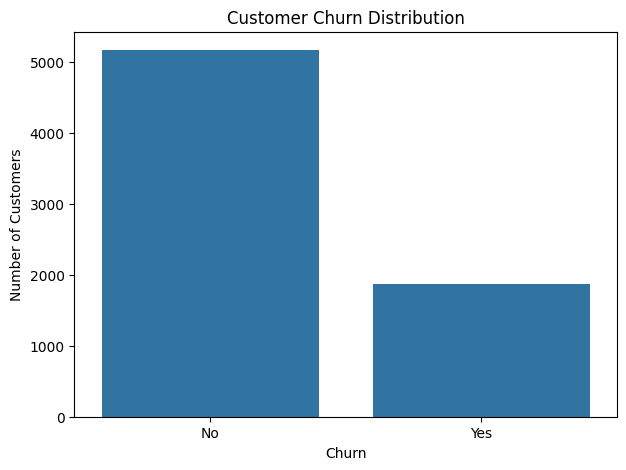

In [ ]:
# Visualize customer churn

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

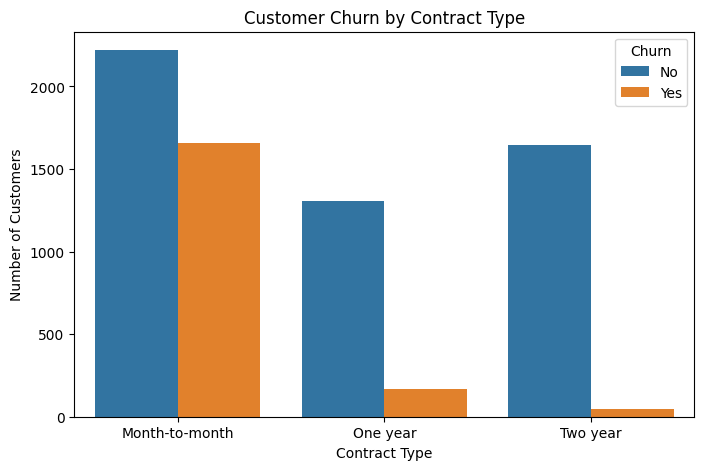

In [ ]:
# Churn by contract type

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

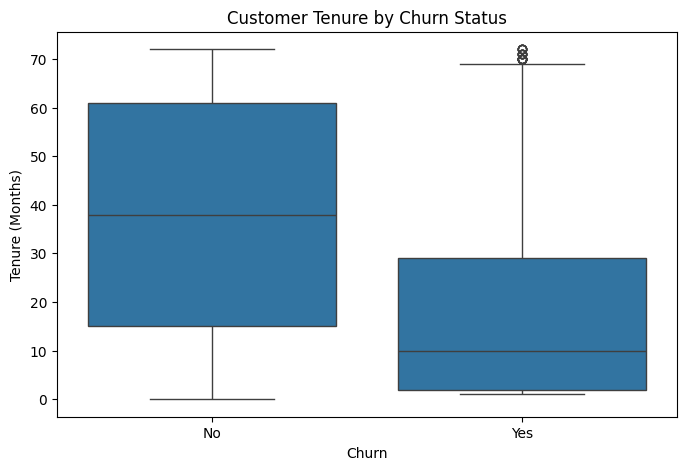

In [ ]:
# Compare tenure between churned and retained customers

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

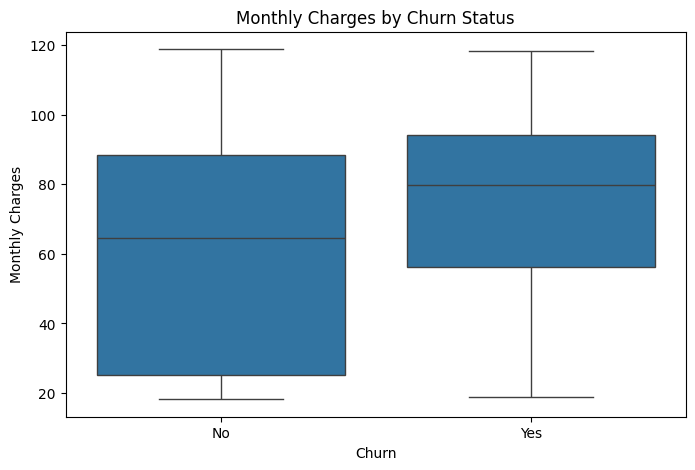

In [ ]:
# Monthly charges by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [ ]:
# Prepare features and target

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Feature shape: (7043, 19)
Target shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [ ]:
# Preprocessing pipeline

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Create Logistic Regression model

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

print("Logistic Regression model created!")

Logistic Regression model created!


In [ ]:
# Train the supervised learning model

logistic_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
# Make predictions on test data

y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 73.81%


In [ ]:
# Classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# Calculate ROC-AUC score

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8413


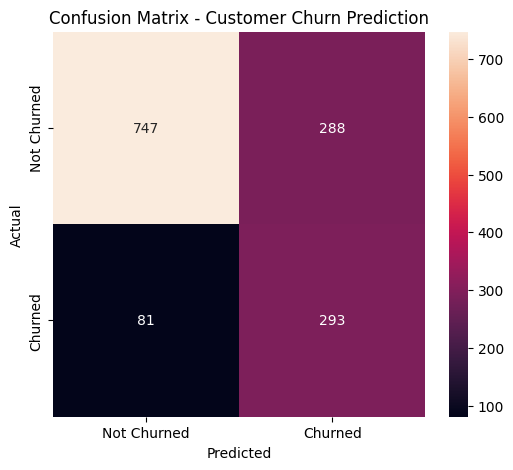

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned']
)

plt.title('Confusion Matrix - Customer Churn Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
# Select numerical features for customer segmentation

cluster_data = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
].copy()

print("Clustering data:")
print(cluster_data.head())

Clustering data:
   tenure  MonthlyCharges  TotalCharges  SeniorCitizen
0       1           29.85         29.85              0
1      34           56.95       1889.50              0
2       2           53.85        108.15              0
3      45           42.30       1840.75              0
4       2           70.70        151.65              0


In [ ]:
# Scale the clustering features

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)

print("Clustering data scaled successfully!")

Clustering data scaled successfully!


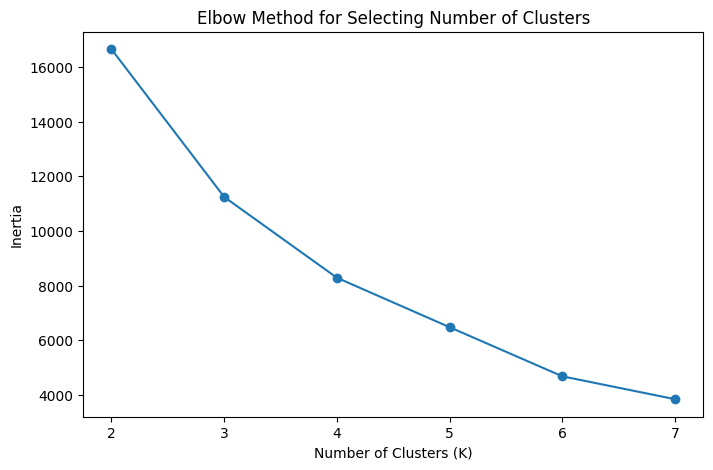

In [ ]:
# Elbow Method

inertia = []

K_values = range(2, 8)

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertia,
    marker='o'
)

plt.title('Elbow Method for Selecting Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

In [ ]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    cluster_scaled
)

print("Clusters created successfully!")

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

Clusters created successfully!

Number of customers in each cluster:
Cluster
0    1972
1    1754
2    2175
3    1142
Name: count, dtype: int64


In [ ]:
# Calculate Silhouette Score

silhouette = silhouette_score(
    cluster_scaled,
    df['Cluster']
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4279


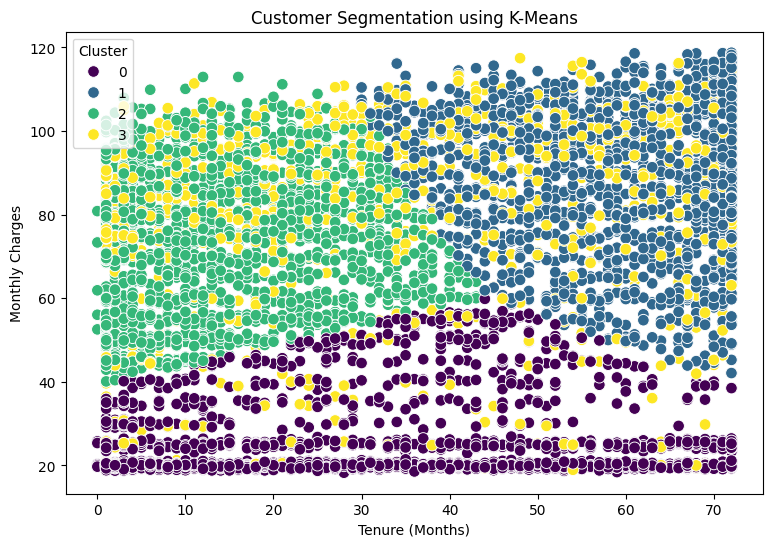

In [ ]:
# Visualize customer clusters

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')

plt.show()

In [ ]:
# Analyze cluster characteristics

cluster_summary = df.groupby('Cluster')[
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
].mean()

print("Cluster Characteristics:")
print(cluster_summary.round(2))

Cluster Characteristics:
         tenure  MonthlyCharges  TotalCharges  SeniorCitizen
Cluster                                                     
0         29.55           25.68        792.77            0.0
1         58.84           88.70       5211.78            0.0
2         13.10           72.98        991.81            0.0
3         33.30           79.82       2810.47            1.0


In [ ]:
# Compare churn rate across customer clusters

cluster_churn = pd.crosstab(
    df['Cluster'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn percentage within each cluster:")
print(cluster_churn.round(2))

Churn percentage within each cluster:
Churn       No    Yes
Cluster              
0        89.30  10.70
1        86.72  13.28
2        56.37  43.63
3        58.32  41.68


In [ ]:
# Final Project Summary

print("==============================================")
print("WEEK 6 CAPSTONE PROJECT SUMMARY")
print("==============================================")

print("Project: Telecom Customer Churn Prediction")
print("Dataset:", df.shape[0], "customers")
print("Features:", df.shape[1] - 1)

print("\n--- SUPERVISED LEARNING ---")
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\n--- UNSUPERVISED LEARNING ---")
print("Algorithm: K-Means Clustering")
print("Number of Clusters: 4")
print(f"Silhouette Score: {silhouette:.4f}")

print("==============================================")

WEEK 6 CAPSTONE PROJECT SUMMARY
Project: Telecom Customer Churn Prediction
Dataset: 7043 customers
Features: 21

--- SUPERVISED LEARNING ---
Logistic Regression Accuracy: 73.81%
ROC-AUC Score: 0.8413

--- UNSUPERVISED LEARNING ---
Algorithm: K-Means Clustering
Number of Clusters: 4
Silhouette Score: 0.4279
